# Ensemble Diversity Analysis — Complete
Covers: pairwise disagreement, Q-statistic, error correlation, ambiguity decomposition, correlated mistake analysis, and leave-one-out gain.

## 0. Imports & Data Loading

In [1]:
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
from scipy.special import expit as sigmoid

with open('JAADbeh_results.json', 'r') as f:
    results = json.load(f)

print('Available keys:', list(results.keys()))

Available keys: ['x3', 'x1', 'x2', 'x1_x2', 'x1_x3', 'x2_x3', 'x1_x2_x3']


## 1. Helper Utilities

In [2]:
# ── ground truth ──────────────────────────────────────────────────────────────
def get_gt(model_name='x1'):
    gt = np.array(results[model_name]['test_gts'])
    if gt.ndim > 1:
        gt = np.array(list(itertools.chain(*gt)))
    return gt.astype(int)

gt = get_gt()
N  = len(gt)

# ── fetch arrays ─────────────────────────────────────────────────────────────
def get_preds(key):  return np.array(results[key]['preds']).astype(int)
def get_probs(key):  return np.array(results[key]['probs']).squeeze()

# ── error vector (1 = wrong) ──────────────────────────────────────────────────
def errors(key):     return (get_preds(key) != gt).astype(int)

# ── class balance ─────────────────────────────────────────────────────────────
pos = gt.sum()
print(f'Dataset size : {N}')
print(f'Positive     : {int(pos)}  ({pos/N:.2%})')
print(f'Negative     : {N-int(pos)}  ({(N-pos)/N:.2%})')

Dataset size : 93950
Positive     : 40505  (43.11%)
Negative     : 53445  (56.89%)


## 2. Individual Model Accuracy

,errors,accuracy
model,,
x1,"38,264",0.5927
x2,"28,462",0.6971
x3,"36,625",0.6102
x1_x2,"37,128",0.6048
x1_x3,"39,054",0.5843
x2_x3,"31,381",0.6660
x1_x2_x3,"33,181",0.6468


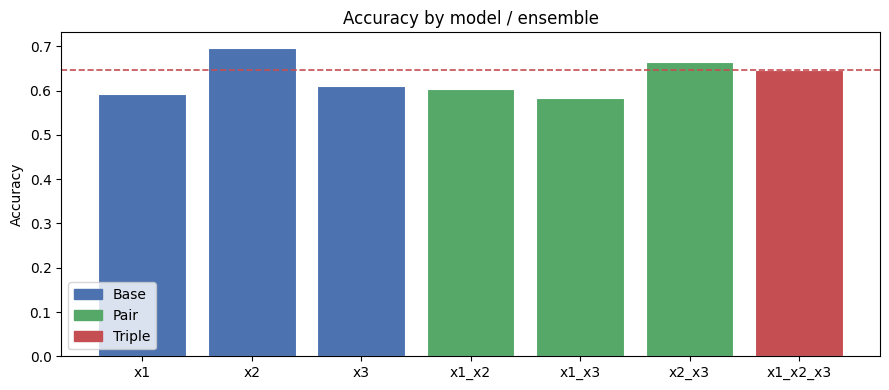

In [3]:
BASE_MODELS   = ['x1', 'x2', 'x3']
PAIR_MODELS   = ['x1_x2', 'x1_x3', 'x2_x3']
TRIPLE_MODELS = ['x1_x2_x3']
ALL_MODELS    = BASE_MODELS + PAIR_MODELS + TRIPLE_MODELS

rows = []
for key in ALL_MODELS:
    p      = get_preds(key)
    n_err  = int((p != gt).sum())
    acc    = 1 - n_err / N
    rows.append({'model': key, 'errors': n_err, 'accuracy': acc})

acc_df = pd.DataFrame(rows).set_index('model')
display(acc_df.style.format({'errors': '{:,}', 'accuracy': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4C72B0']*3 + ['#55A868']*3 + ['#C44E52']
ax.bar(acc_df.index, acc_df['accuracy'], color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(acc_df.loc['x1_x2_x3','accuracy'], color='#C44E52', linestyle='--', linewidth=1.2, label='Full ensemble')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by model / ensemble')
patches = [mpatches.Patch(color='#4C72B0', label='Base'),
           mpatches.Patch(color='#55A868', label='Pair'),
           mpatches.Patch(color='#C44E52', label='Triple')]
ax.legend(handles=patches)
plt.tight_layout(); plt.show()

## 3. Pairwise Diversity Metrics (Base Models)

In [4]:
def disagreement(e_i, e_j):
    """Fraction of samples where the two models disagree."""
    return float(np.mean(e_i != e_j))

def q_statistic(e_i, e_j):
    """Yule's Q: near 0 / negative = diverse, near +1 = redundant."""
    N11 = np.sum((e_i==1) & (e_j==1))
    N00 = np.sum((e_i==0) & (e_j==0))
    N10 = np.sum((e_i==1) & (e_j==0))
    N01 = np.sum((e_i==0) & (e_j==1))
    denom = N11*N00 + N10*N01
    return float((N11*N00 - N10*N01) / (denom + 1e-9))

def error_corr(e_i, e_j):
    return float(pearsonr(e_i, e_j)[0])

def prob_corr(k_i, k_j):
    return float(pearsonr(get_probs(k_i), get_probs(k_j))[0])

pairs = list(itertools.combinations(BASE_MODELS, 2))
pairwise_rows = []
for a, b in pairs:
    ea, eb = errors(a), errors(b)
    pairwise_rows.append({
        'pair'        : f'{a} vs {b}',
        'disagreement': disagreement(ea, eb),
        'Q_statistic' : q_statistic(ea, eb),
        'error_corr'  : error_corr(ea, eb),
        'prob_corr'   : prob_corr(a, b),
    })

pw_df = pd.DataFrame(pairwise_rows).set_index('pair')
display(pw_df.style.format('{:.4f}').background_gradient(
    subset=['Q_statistic','error_corr','prob_corr'], cmap='RdYlGn_r')
        .background_gradient(subset=['disagreement'], cmap='RdYlGn'))
print('\nInterpretation guide:')
print('  disagreement  → higher = more diverse (good)')
print('  Q_statistic   → lower / negative = more diverse (good)')
print('  error_corr    → lower = more diverse (good)')
print('  prob_corr     → lower = more diverse (good)')

,disagreement,Q_statistic,error_corr,prob_corr
pair,,,,
x1 vs x2,0.3861,0.3588,0.1713,0.2493
x1 vs x3,0.3876,0.3801,0.1919,0.2567
x2 vs x3,0.2828,0.7060,0.3878,0.4991



Interpretation guide:
  disagreement  → higher = more diverse (good)
  Q_statistic   → lower / negative = more diverse (good)
  error_corr    → lower = more diverse (good)
  prob_corr     → lower = more diverse (good)


## 4. Diversity Matrices (Heat Maps)

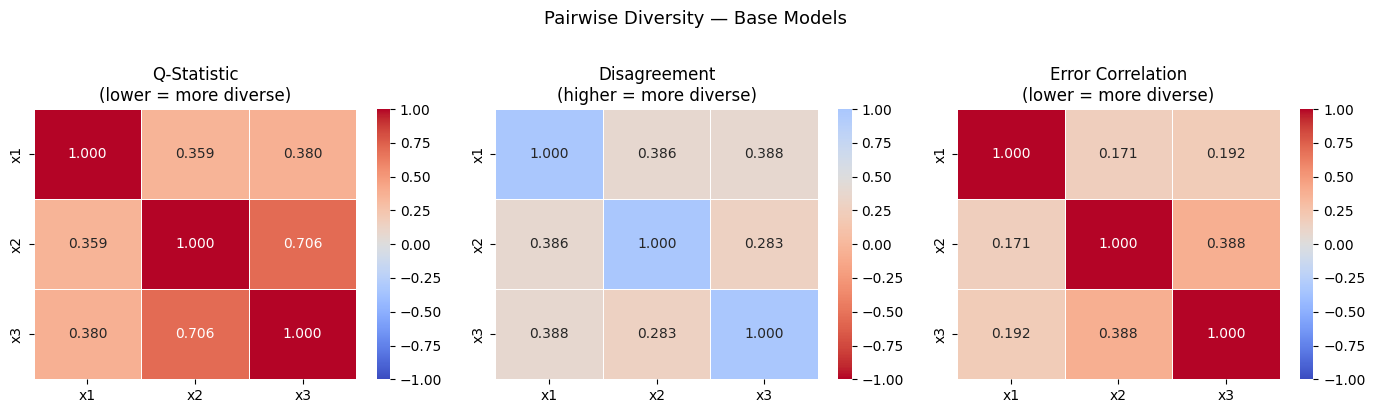

In [5]:
M = len(BASE_MODELS)

def build_matrix(fn, models):
    mat = np.eye(len(models))
    for i, j in itertools.combinations(range(len(models)), 2):
        v = fn(errors(models[i]), errors(models[j]))
        mat[i,j] = mat[j,i] = v
    return mat

Q_mat    = build_matrix(q_statistic,  BASE_MODELS)
dis_mat  = build_matrix(disagreement, BASE_MODELS)
ecor_mat = build_matrix(error_corr,   BASE_MODELS)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mat, title, cmap, center in zip(
        axes,
        [Q_mat, dis_mat, ecor_mat],
        ['Q-Statistic\n(lower = more diverse)',
         'Disagreement\n(higher = more diverse)',
         'Error Correlation\n(lower = more diverse)'],
        ['coolwarm', 'coolwarm_r', 'coolwarm'],
        [0, 0.5, 0]):
    sns.heatmap(mat, annot=True, fmt='.3f', xticklabels=BASE_MODELS,
                yticklabels=BASE_MODELS, ax=ax, cmap=cmap,
                center=center, vmin=-1, vmax=1, linewidths=0.5)
    ax.set_title(title)
plt.suptitle('Pairwise Diversity — Base Models', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 5. Ambiguity Decomposition
> Ensemble Error = Avg Individual Error − **Diversity**
>
> A positive diversity term means the ensemble genuinely reduces error.

=== x1 + x2 + x3 ===
  Avg individual MSE : 0.275031
  Ensemble MSE       : 0.215400
  Diversity term     : 0.059631  (21.7% of avg individual loss)


,avg_ind_MSE,ens_MSE,diversity,div_pct
ensemble,,,,
x1_x2,0.277012,0.222548,0.054465,19.66%
x1_x3,0.307829,0.255805,0.052024,16.90%
x2_x3,0.240252,0.212570,0.027681,11.52%
x1_x2_x3,0.275031,0.215400,0.059631,21.68%


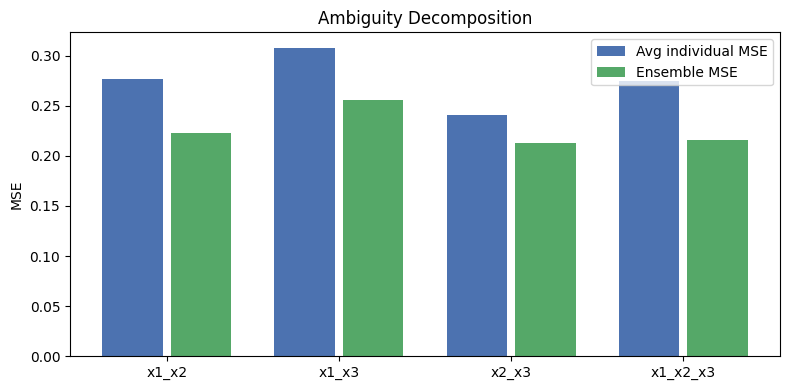

In [6]:
def ambiguity_decomposition(model_keys, ensemble_key):
    """
    Uses MSE on probabilities (soft version of the decomposition).
    Returns: ensemble_loss, avg_individual_loss, diversity_term
    """
    probs   = np.stack([get_probs(k) for k in model_keys], axis=1)  # (N, M)
    ens_prob = probs.mean(axis=1)                                     # simple avg
    y = gt.astype(float)

    ens_loss  = float(np.mean((ens_prob - y)**2))
    ind_losses = np.mean((probs - y[:,None])**2, axis=0)
    avg_ind   = float(ind_losses.mean())
    diversity = avg_ind - ens_loss                                    # always >= 0
    return ens_loss, avg_ind, diversity

# ── all base models ───────────────────────────────────────────────────────────
ens_loss, avg_ind, div = ambiguity_decomposition(BASE_MODELS, 'x1_x2_x3')
print('=== x1 + x2 + x3 ===')
print(f'  Avg individual MSE : {avg_ind:.6f}')
print(f'  Ensemble MSE       : {ens_loss:.6f}')
print(f'  Diversity term     : {div:.6f}  ({div/avg_ind:.1%} of avg individual loss)')

# ── pair-level ────────────────────────────────────────────────────────────────
ambi_rows = []
for key in PAIR_MODELS:
    parts = key.split('_')     # e.g. ['x1','x2']
    el, ai, dv = ambiguity_decomposition(parts, key)
    ambi_rows.append({'ensemble': key, 'avg_ind_MSE': ai,
                      'ens_MSE': el, 'diversity': dv,
                      'div_pct': dv/ai})

# triple
el, ai, dv = ambiguity_decomposition(BASE_MODELS, 'x1_x2_x3')
ambi_rows.append({'ensemble':'x1_x2_x3','avg_ind_MSE':ai,'ens_MSE':el,
                  'diversity':dv,'div_pct':dv/ai})

ambi_df = pd.DataFrame(ambi_rows).set_index('ensemble')
display(ambi_df.style.format({'avg_ind_MSE':'{:.6f}','ens_MSE':'{:.6f}',
                              'diversity':'{:.6f}','div_pct':'{:.2%}'})
        .background_gradient(subset=['diversity','div_pct'], cmap='Greens'))

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ambi_df))
ax.bar(x - 0.2, ambi_df['avg_ind_MSE'], 0.35, label='Avg individual MSE', color='#4C72B0')
ax.bar(x + 0.2, ambi_df['ens_MSE'],     0.35, label='Ensemble MSE',       color='#55A868')
ax.set_xticks(x); ax.set_xticklabels(ambi_df.index)
ax.set_ylabel('MSE'); ax.set_title('Ambiguity Decomposition')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Correlated Mistakes Analysis
When two models agree, how often are they *both wrong*? High rate = harmful correlation.

In [7]:
def correlated_mistake_analysis(key_a, key_b):
    pa, pb = get_preds(key_a), get_preds(key_b)
    agree_mask   = pa == pb
    agreed_preds = pa[agree_mask]
    agreed_gt    = gt[agree_mask]
    n_agree      = int(agree_mask.sum())
    n_corr_err   = int((agreed_preds != agreed_gt).sum())
    # mistake union
    m_a = set(np.where(pa != gt)[0])
    m_b = set(np.where(pb != gt)[0])
    union = len(m_a | m_b)
    intersect = len(m_a & m_b)
    return {
        'pair'              : f'{key_a} vs {key_b}',
        'n_agree'           : n_agree,
        'agree_pct'         : n_agree / N,
        'correlated_errors' : n_corr_err,
        'corr_err_rate'     : n_corr_err / n_agree,
        'mistake_union'     : union,
        'mistake_intersect' : intersect,
        'jaccard_err'       : intersect / union if union > 0 else 0,
    }

# base pairs
cm_rows = [correlated_mistake_analysis(a, b) for a,b in pairs]
# ablation pairs (ensemble vs held-out)
ablation_pairs = [('x1_x2','x3'), ('x1_x3','x2'), ('x2_x3','x1')]
cm_rows += [correlated_mistake_analysis(a, b) for a,b in ablation_pairs]

cm_df = pd.DataFrame(cm_rows).set_index('pair')
display(cm_df.style.format({
    'n_agree':'{:,}', 'agree_pct':'{:.2%}',
    'correlated_errors':'{:,}', 'corr_err_rate':'{:.2%}',
    'mistake_union':'{:,}', 'mistake_intersect':'{:,}',
    'jaccard_err':'{:.4f}'
}).background_gradient(subset=['corr_err_rate','jaccard_err'], cmap='Reds'))

print('\nJaccard error index: fraction of combined mistakes that are shared.')
print('Higher = more correlated failure modes = less complementary.')

,n_agree,agree_pct,correlated_errors,corr_err_rate,mistake_union,mistake_intersect,jaccard_err
pair,,,,,,,
x1 vs x2,"57,674",61.39%,"15,225",26.40%,"51,501","15,225",0.2956
x1 vs x3,"57,533",61.24%,"19,236",33.43%,"55,653","19,236",0.3456
x2 vs x3,"67,385",71.72%,"19,261",28.58%,"45,826","19,261",0.4203
x1_x2 vs x3,"62,547",66.57%,"21,175",33.85%,"52,578","21,175",0.4027
x1_x3 vs x2,"64,180",68.31%,"18,873",29.41%,"48,643","18,873",0.3880
x2_x3 vs x1,"59,127",62.93%,"17,411",29.45%,"52,234","17,411",0.3333



Jaccard error index: fraction of combined mistakes that are shared.
Higher = more correlated failure modes = less complementary.


## 7. Leave-One-Out Gain Analysis
Does removing a model from the full ensemble hurt or help?

,remaining,remaining_acc,full_ensemble_acc,acc_drop,unique_contribution
removed,,,,,
x1,x2_x3,0.6660,0.6468,-0.0192,"-1,800"
x2,x1_x3,0.5843,0.6468,+0.0625,"+5,873"
x3,x1_x2,0.6048,0.6468,+0.0420,"+3,947"


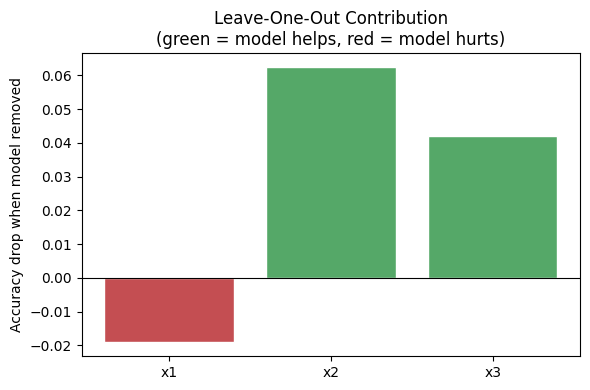


Full ensemble (x1+x2+x3) accuracy: 0.6468


In [8]:
full_err  = int((get_preds('x1_x2_x3') != gt).sum())
full_acc  = 1 - full_err / N

loo_rows = []
loo_map  = {'x1': 'x2_x3', 'x2': 'x1_x3', 'x3': 'x1_x2'}
for removed, remaining_key in loo_map.items():
    rem_err = int((get_preds(remaining_key) != gt).sum())
    rem_acc = 1 - rem_err / N
    loo_rows.append({
        'removed'          : removed,
        'remaining'        : remaining_key,
        'remaining_acc'    : rem_acc,
        'full_ensemble_acc': full_acc,
        'acc_drop'         : full_acc - rem_acc,   # positive = model was helping
        'unique_contribution': rem_err - full_err, # errors added when model removed
    })

loo_df = pd.DataFrame(loo_rows).set_index('removed')
display(loo_df.style.format({
    'remaining_acc':'{:.4f}', 'full_ensemble_acc':'{:.4f}',
    'acc_drop':'{:+.4f}', 'unique_contribution':'{:+,}'
}).background_gradient(subset=['acc_drop'], cmap='RdYlGn'))

fig, ax = plt.subplots(figsize=(6,4))
colors = ['#55A868' if v > 0 else '#C44E52' for v in loo_df['acc_drop']]
ax.bar(loo_df.index, loo_df['acc_drop'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy drop when model removed')
ax.set_title('Leave-One-Out Contribution\n(green = model helps, red = model hurts)')
plt.tight_layout(); plt.show()

print(f'\nFull ensemble (x1+x2+x3) accuracy: {full_acc:.4f}')

## 8. Ensemble Necessity Dashboard
Consolidates all metrics into a single justification table.

In [9]:
best_single_acc = acc_df.loc[BASE_MODELS, 'accuracy'].max()
best_single     = acc_df.loc[BASE_MODELS, 'accuracy'].idxmax()
full_ens_acc    = acc_df.loc['x1_x2_x3', 'accuracy']
gain_over_best  = full_ens_acc - best_single_acc

avg_pairwise_q  = pw_df['Q_statistic'].mean()
avg_disagreement= pw_df['disagreement'].mean()
avg_err_corr    = pw_df['error_corr'].mean()

ens_loss, avg_ind, div = ambiguity_decomposition(BASE_MODELS, 'x1_x2_x3')

print('=' * 55)
print('        ENSEMBLE DIVERSITY ANALYSIS SUMMARY')
print('=' * 55)
print(f'  Best single model      : {best_single}  ({best_single_acc:.4f})')
print(f'  Full ensemble accuracy : {full_ens_acc:.4f}')
print(f'  Gain over best single  : {gain_over_best:+.4f}')
print()
print(f'  Avg pairwise Q-stat    : {avg_pairwise_q:.4f}  (ideal ≤ 0)')
print(f'  Avg disagreement       : {avg_disagreement:.4f}  (ideal → 0.5)')
print(f'  Avg error correlation  : {avg_err_corr:.4f}  (ideal → 0)')
print()
print(f'  Diversity term (MSE)   : {div:.6f}')
print(f'  Diversity / avg indiv  : {div/avg_ind:.2%}')
print('=' * 55)

# ── verdict ───────────────────────────────────────────────────────────────────
diverse   = avg_pairwise_q < 0.5 and avg_disagreement > 0.1
effective = gain_over_best > 0
print()
if diverse and effective:
    print('✅ VERDICT: Ensemble is DIVERSE and EFFECTIVE. Justified.')
elif diverse and not effective:
    print('⚠️  VERDICT: Models are diverse but ensemble offers no accuracy gain.')
    print('   Consider: stronger base models or a learned meta-learner.')
elif not diverse and effective:
    print('⚠️  VERDICT: Models are similar but ensemble still helps marginally.')
    print('   Gain likely comes from variance reduction, not complementary errors.')
else:
    print('❌ VERDICT: Low diversity AND no accuracy gain. Ensemble NOT justified.')
    print('   Use the best single model instead.')

        ENSEMBLE DIVERSITY ANALYSIS SUMMARY
  Best single model      : x2  (0.6971)
  Full ensemble accuracy : 0.6468
  Gain over best single  : -0.0502

  Avg pairwise Q-stat    : 0.4816  (ideal ≤ 0)
  Avg disagreement       : 0.3522  (ideal → 0.5)
  Avg error correlation  : 0.2503  (ideal → 0)

  Diversity term (MSE)   : 0.059631
  Diversity / avg indiv  : 21.68%

⚠️  VERDICT: Models are diverse but ensemble offers no accuracy gain.
   Consider: stronger base models or a learned meta-learner.
